# Surrogate Factory — UCFatigue
## Chapter 9. Model Validation
Objectives:
- **9.0** Validate the train/test split quality (voxel tesselation proximity method).
- **9.0b** Data coverage — distributions and PCA scatter across Train / Val / Test.
- **9.1** Predict fatigue loads on the test set.
- **9.2** Compute metrics (R², MAE, quantile90).
- **9.2b** KS distribution tests: train vs test residuals.
- **9.2c** Residual distribution plots.
- **9.3** Validate against requirements defined in SF_1.
- **9.4** Generate scatter and ratio plots.
- **9.5** Validation Report — full extended validation HTML report per model (validationlib template).
- **9.6** MLflow EDA Report.

### 0. Workflow initialisation

In [1]:
import sys
from pathlib import Path

# add repo root so validationlib is importable
repo_root = str(Path('..').resolve().parent)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from IPython.display import display, HTML, JSON
from surrogate_factory.workflow import Workflow

workflow = Workflow('pipeline_config.yaml')
workflow.resume()

2026-07-01 11:39:26 - SurrogateFactoryLogs - INFO - Initializing Workflow...
2026-07-01 11:39:26 - SurrogateFactoryLogs - INFO - Setting up Workflow folders and paths...
2026-07-01 11:39:26 - SurrogateFactoryLogs - INFO - Changing working directory to Data folder: /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data
2026-07-01 11:39:26 - SurrogateFactoryLogs - INFO - Loading default metadata schema...
2026-07-01 11:39:26 - SurrogateFactoryLogs - INFO - Tracker requested: 'mlflow'
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Setting up MLflow tracking environment...
Setting tracking uri: file:///Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/mlruns
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Adding methods to Catalog from configuration.
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Workflow initialization completed successfully.
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Resuming workflow job: 'UCFATIGUE_1'
2026-07-01 11:39:27 

### 9. Model Validation

In [2]:
workflow.import_metadata(stage_name='SF_9_Model_Validation')

2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Importing metadata for stage: 'SF_9_Model_Validation'
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Updating metadata for stage 'Model_Validation' in memory.


In [3]:
Train_set = workflow.load_data(workflow.config['job_name'] + '_Train_set.csv')
Val_set   = workflow.load_data(workflow.config['job_name'] + '_Val_set.csv')
Test_set  = workflow.load_data(workflow.config['job_name'] + '_Test_set.csv')
print(f'Train set : {Train_set.shape}')
print(f'Val set   : {Val_set.shape}')
print(f'Test set  : {Test_set.shape}')

2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/UCFATIGUE_1_Train_set.csv' (Format: csv)
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (608, 29)
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/UCFATIGUE_1_Val_set.csv' (Format: csv)
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (87, 29)
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/UCFATIGUE_1_Test_set.csv' (Format: csv)
2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (174, 29)
Train set : (608, 29)
Val set   : (87, 29)
Test set  : (174, 29)


#### 9.0 Split Validation
Checks that the train/test split is statistically sound:
- **Residual voxel proportion**: fraction of test points in category combinations not seen in training (target ≤ 0.05).
- **Phacking**: test points too close to training points (data leakage risk).
- **Isolated test**: test points too far from any training point (extrapolation).
- **Chi² p-value**: distribution of train vs test samples per voxel (target ≥ 0.05).

In [4]:
from model_validation.split_val import split_validation
split_result = split_validation(workflow, Train_set, Test_set)

2026-07-01 11:39:27 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'split_validation'

  Metric                       Value    Status  (threshold)
  ----------------------------------------------------------
  Residual voxel proportion  :  0.000   ✓   (≤ 0.05)
  Valid test proportion      :  0.931
  Phacking test proportion   :  0.006
  Isolated test proportion   :  0.063
  Isolated train proportion  :  0.000
  Chi² p-value               : 0.7969   ✓   (≥ 0.05)


#### 9.0b Data Coverage — Train / Val / Test
Distribution of **inputs** and **outputs** across the three sets using validationlib.
- **doubleHistogram**: overlaid histograms for density comparison.
- **PCA scatter**: 2-D projection of 8-D input space coloured by set membership.

Numeric inputs used for plots: ['FLAP', 'Altitude', 'TAS', 'Mass', 'q', 'gamma', 'Xcg(%CMA)']


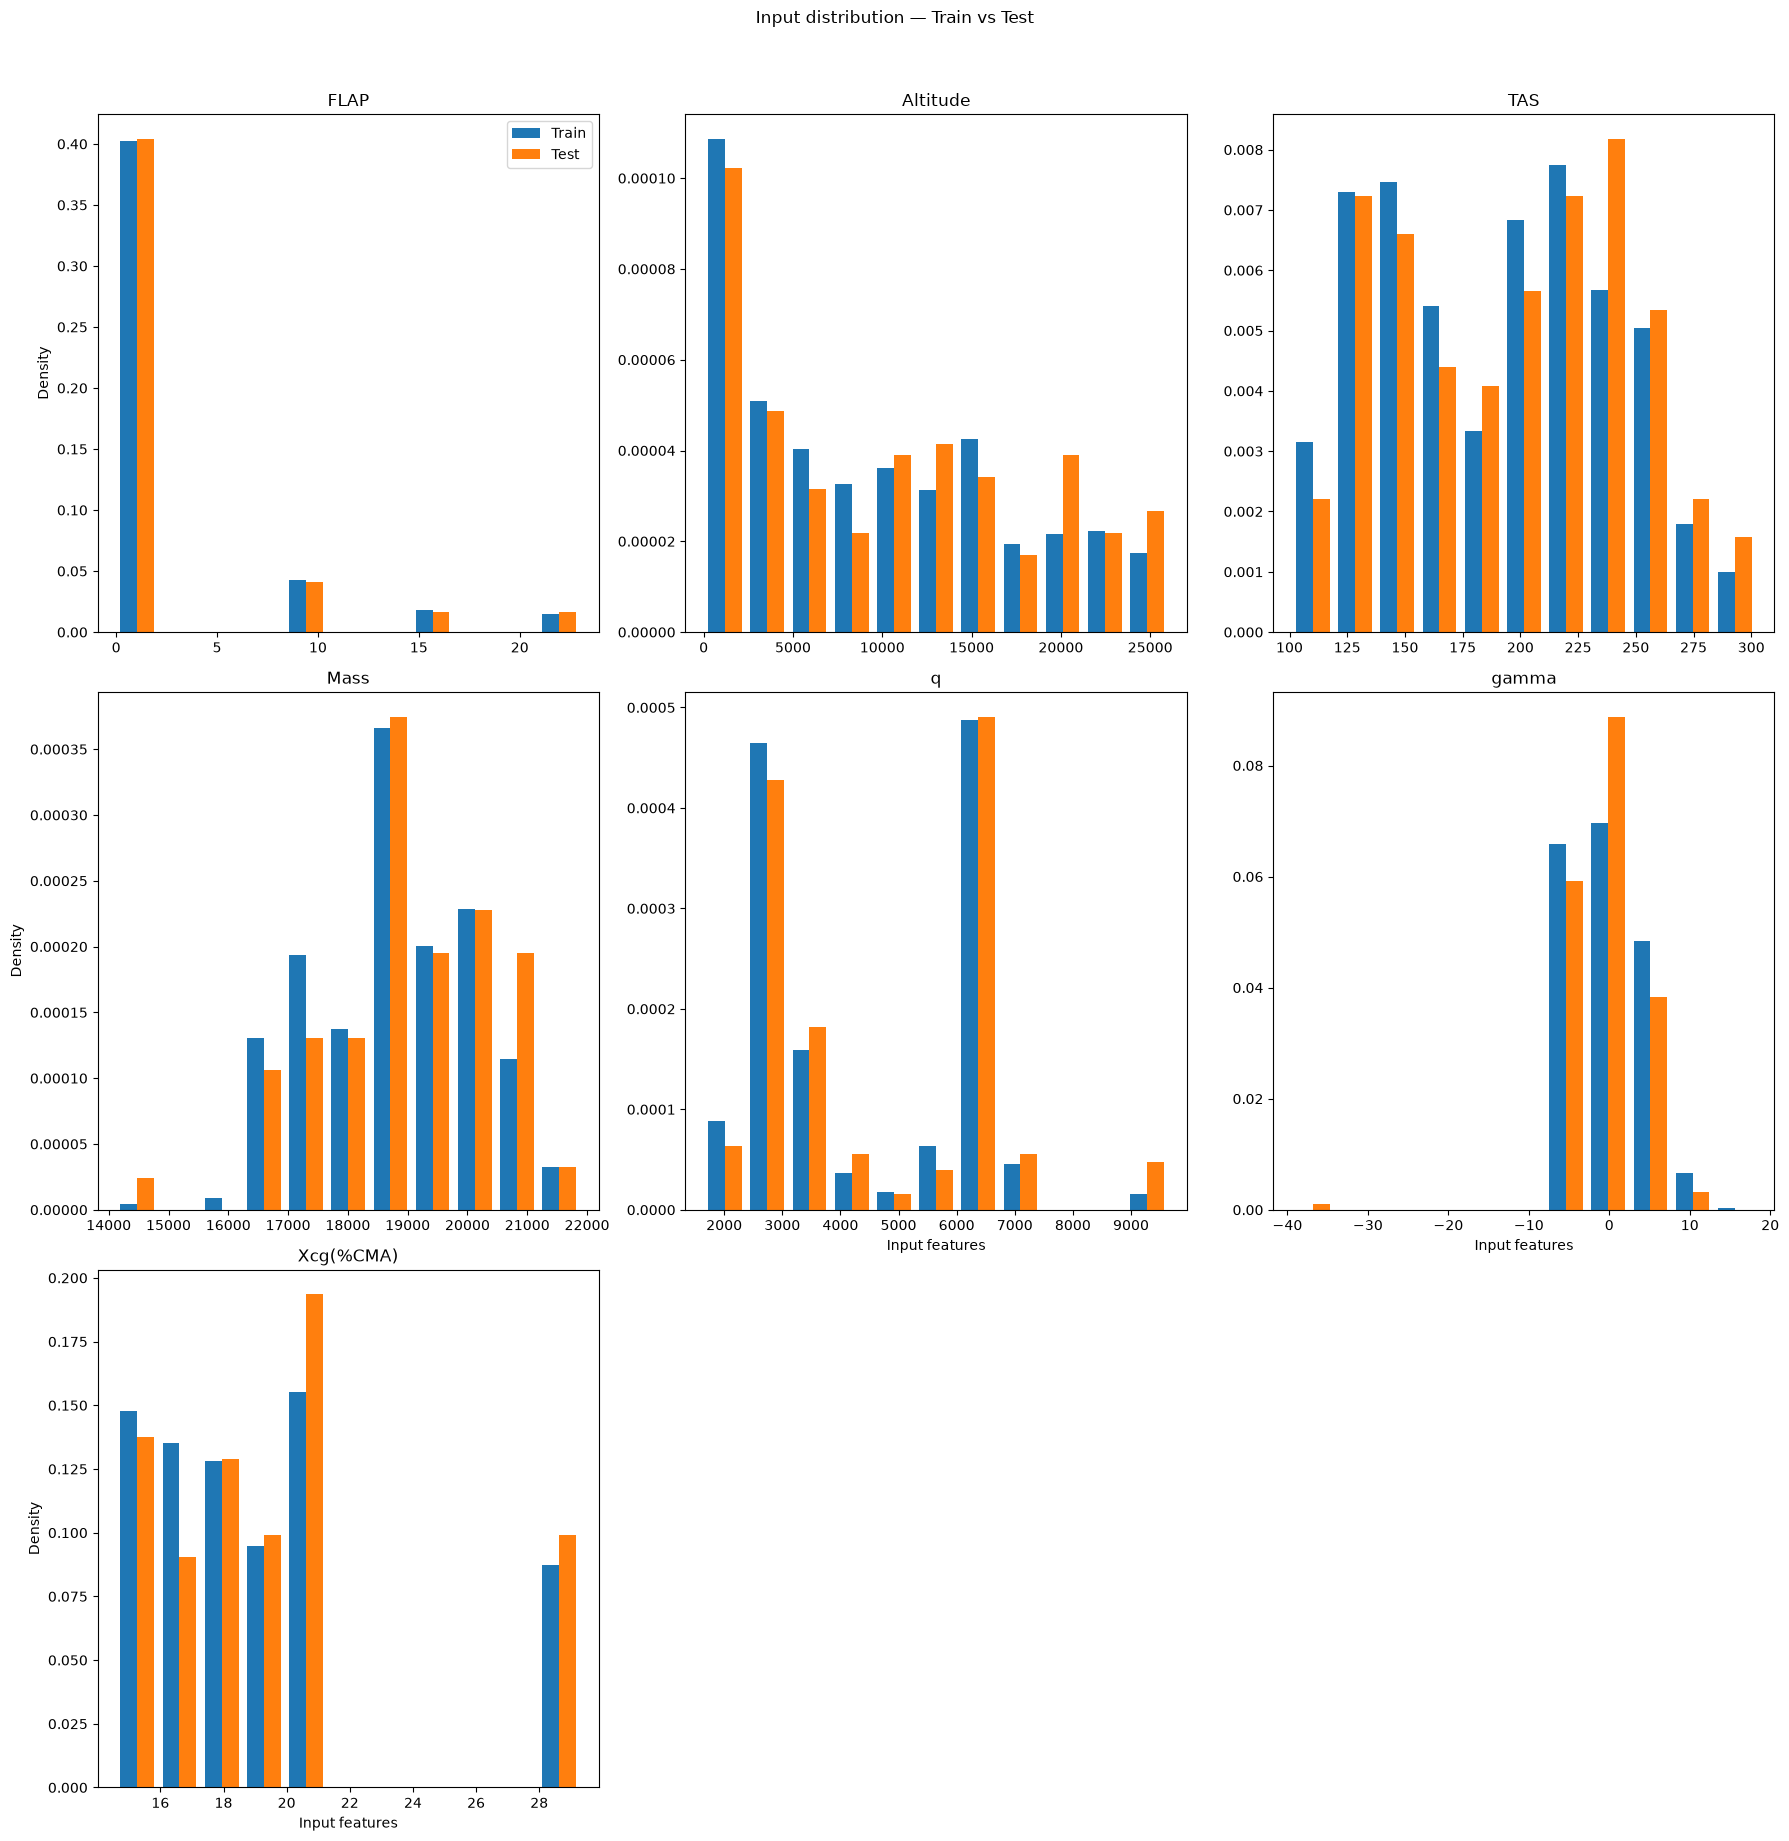

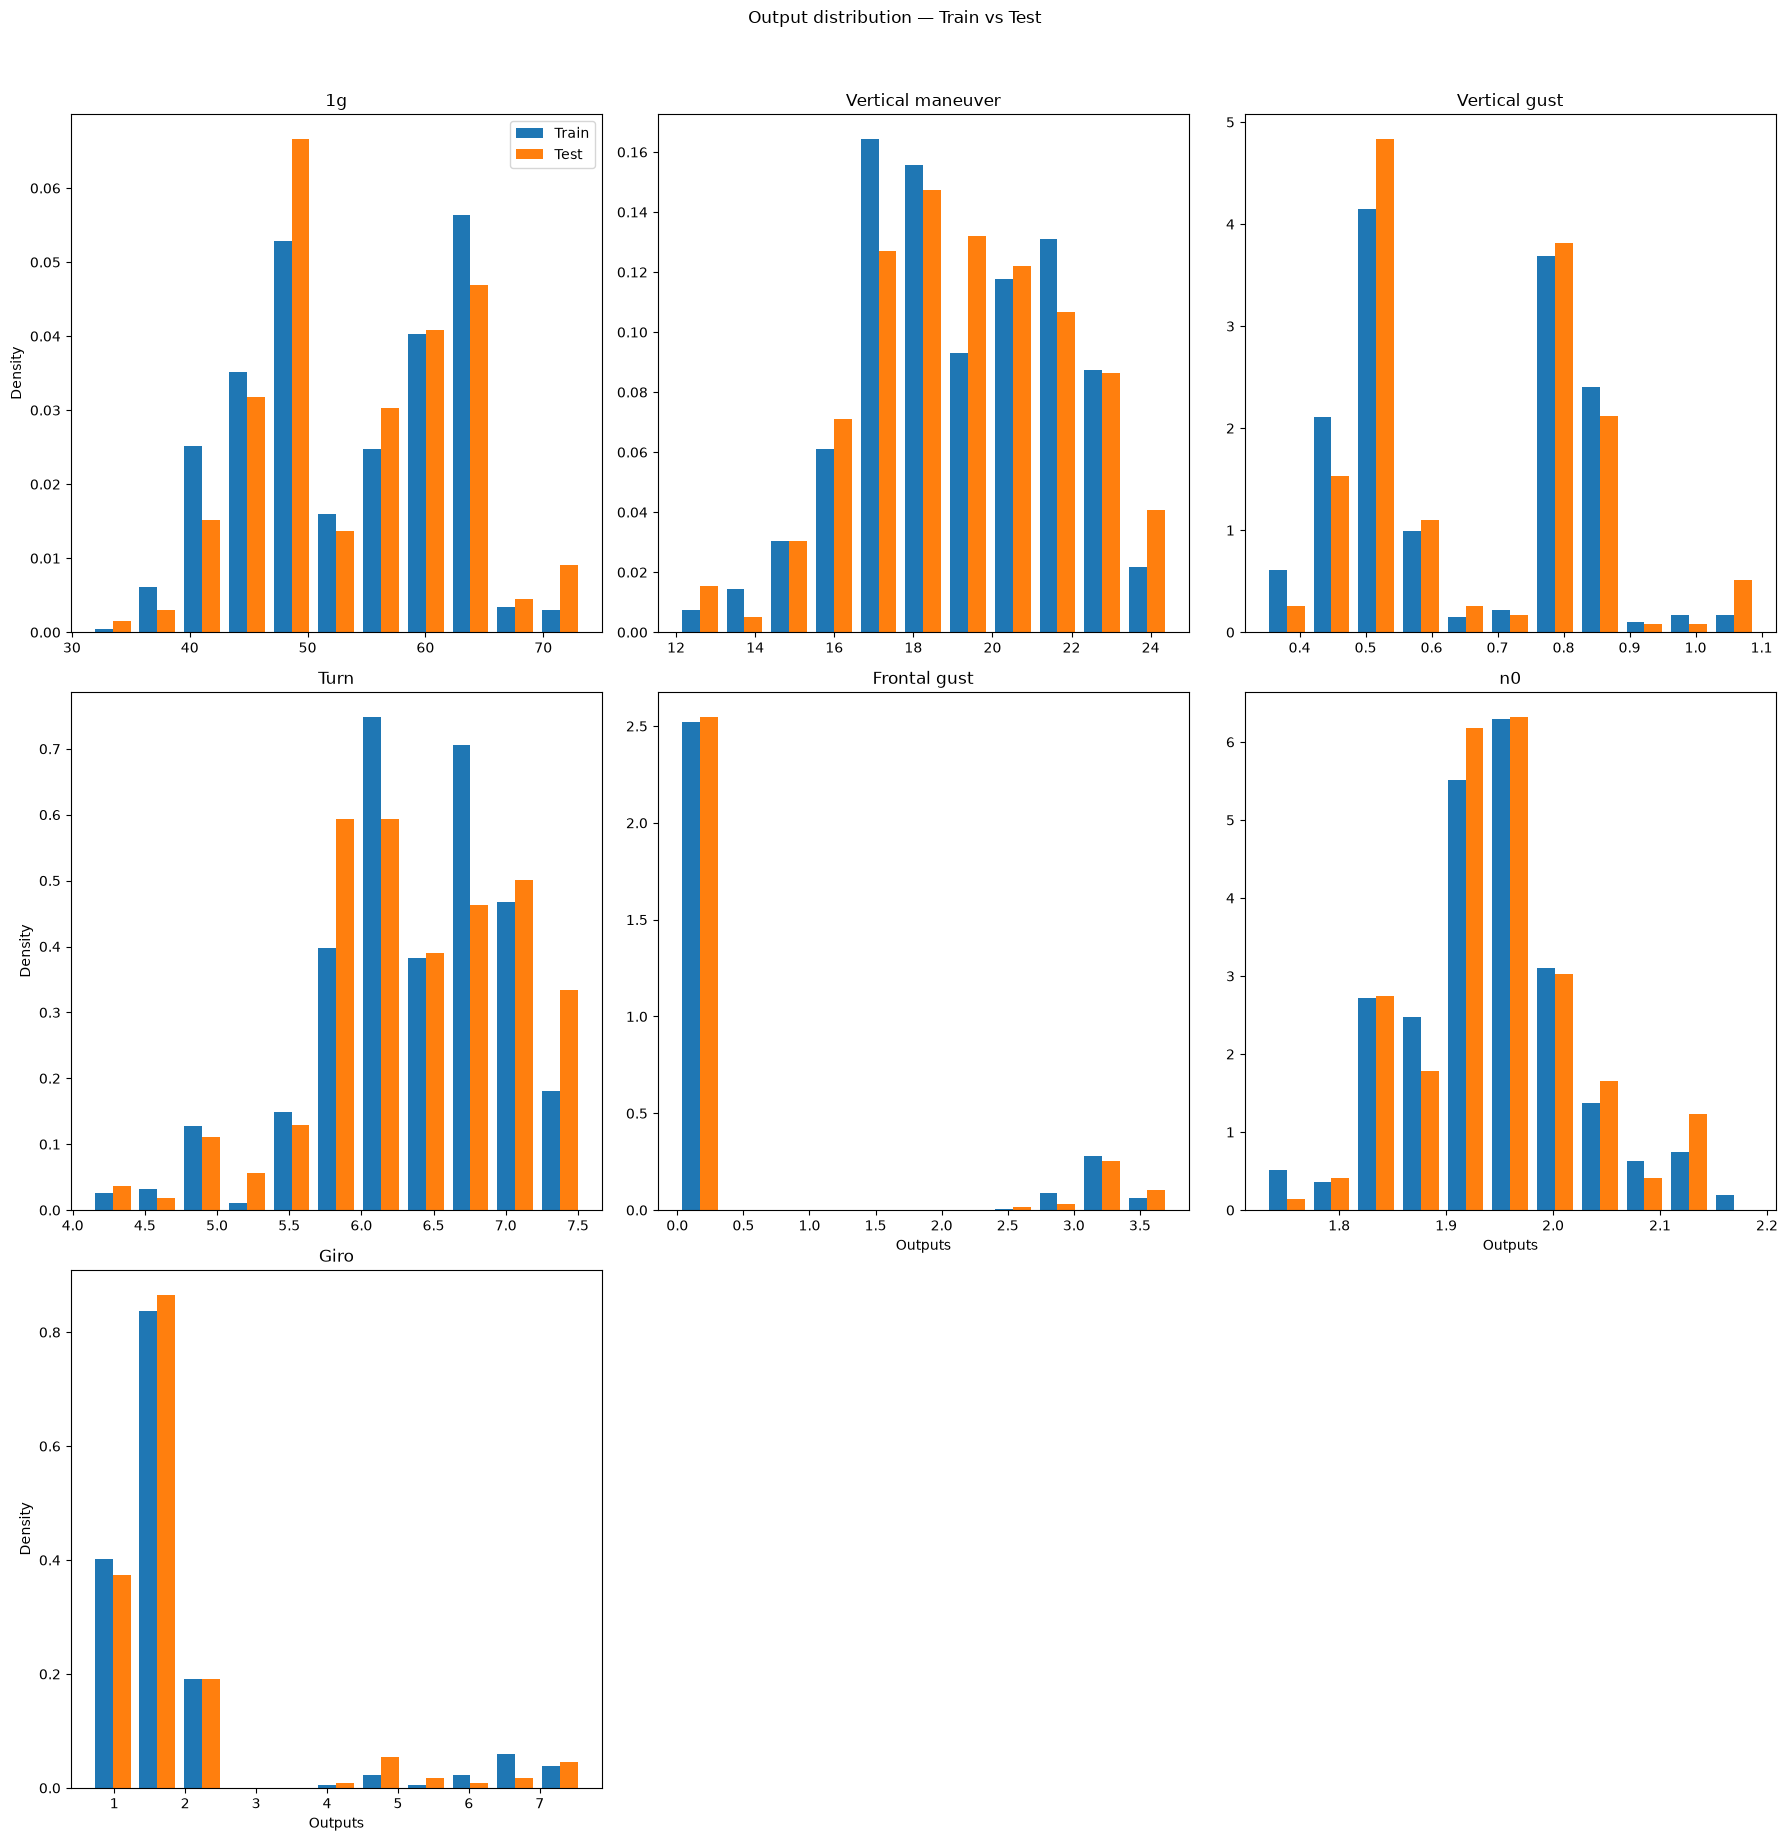

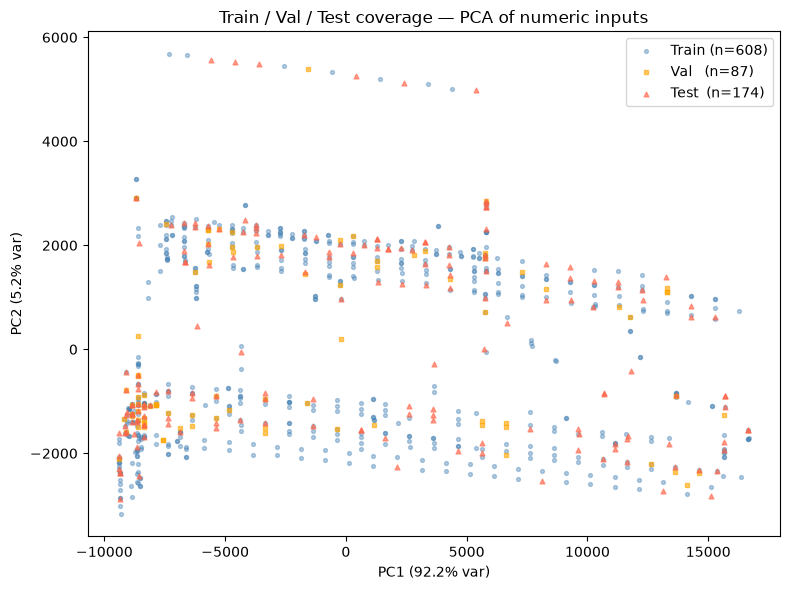

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from validationlib.plots.hist import doubleHistogram
from validationlib.plots.cumu import doublecumulative

ms = workflow.metadata.get_step_data(['metadata', 'Model_Selection'])
inputs  = ms['inputs']
outputs = ms['outputs']

# Exclude categorical columns (strings) — PCA and histograms need numeric data
num_inputs = Train_set[inputs].select_dtypes(include='number').columns.tolist()
print(f'Numeric inputs used for plots: {num_inputs}')

# — Input distribution: Train vs Test (numeric only) —
fig = doubleHistogram(
    Train_set[num_inputs], Test_set[num_inputs],
    x1label='Train', x2label='Test', xlabel='Input features',
    multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
)
fig.suptitle('Input distribution — Train vs Test', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

# — Output distribution: Train vs Test —
fig2 = doubleHistogram(
    Train_set[outputs], Test_set[outputs],
    x1label='Train', x2label='Test', xlabel='Outputs',
    multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
)
fig2.suptitle('Output distribution — Train vs Test', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig2)

# — PCA scatter: 3 sets in 2-D input space (numeric inputs only) —
all_num = pd.concat([Train_set[num_inputs], Val_set[num_inputs], Test_set[num_inputs]], axis=0)
pca = PCA(n_components=2)
pca.fit(all_num)
trPC = pca.transform(Train_set[num_inputs])
vlPC = pca.transform(Val_set[num_inputs])
tsPC = pca.transform(Test_set[num_inputs])

fig3, ax = plt.subplots(figsize=(8, 6))
ax.scatter(trPC[:,0], trPC[:,1], s=8,  alpha=0.4, label=f'Train (n={len(Train_set)})',  color='steelblue')
ax.scatter(vlPC[:,0], vlPC[:,1], s=12, alpha=0.6, label=f'Val   (n={len(Val_set)})',    color='orange',    marker='s')
ax.scatter(tsPC[:,0], tsPC[:,1], s=12, alpha=0.6, label=f'Test  (n={len(Test_set)})',   color='tomato',    marker='^')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'Train / Val / Test coverage — PCA of numeric inputs')
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig3)

#### 9.1 Predictions

In [6]:
from model_validation.prediction import predict
model_output = predict(workflow, Test_set)
train_output = predict(workflow, Train_set)  # needed for KS residual tests
val_output   = predict(workflow, Val_set)    # needed for uncertainty models
model_output.head()

2026-07-01 11:39:29 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'
2026-07-01 11:39:29 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'
2026-07-01 11:39:29 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'


,MLP__1g,MLP__Vertical maneuver,MLP__Vertical gust,MLP__Turn,MLP__Frontal gust,MLP__n0,MLP__Giro,GradientBoosting__1g,GradientBoosting__Vertical maneuver,GradientBoosting__Vertical gust,GradientBoosting__Turn,GradientBoosting__Frontal gust,GradientBoosting__n0,GradientBoosting__Giro
0,64.324841,22.396550,0.852538,6.961862,-0.012125,1.859812,2.273896,64.536167,22.363011,0.846566,6.936925,-0.000092,1.862413,1.847443
1,65.673678,22.307537,0.845350,6.947433,-0.085869,1.759884,1.541311,66.405128,23.230083,0.884321,7.251977,-0.000092,1.903950,2.075564
2,64.407337,22.166164,0.729585,6.936283,-0.012666,1.922614,2.152152,63.944683,21.766743,0.785387,6.747302,-0.000092,1.932950,1.858045
3,74.157251,24.604166,1.084161,7.582078,0.023083,2.038480,1.388231,72.988059,24.319158,1.061712,7.376052,-0.000092,1.876274,2.003683
4,42.127061,14.322500,0.440146,4.932839,3.317435,1.918961,3.070983,42.008031,14.921771,0.435913,4.979810,3.330306,1.877546,5.222344


#### 9.2 Metrics

In [7]:
from model_validation.score import calculate_metrics
metrics = calculate_metrics(workflow, Test_set, model_output)
JSON(metrics)

2026-07-01 11:39:29 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'calculate_metrics'

Output                              R² MLPR² GradientBoosting
--------------------------------------------------------
1g                                  0.9160        0.9797
Vertical maneuver                   0.9116        0.9723
Vertical gust                       0.9377        0.9914
Turn                                0.7544        0.9286
Frontal gust                        0.9794        0.9964
n0                                 -0.7292        0.9317
Giro                               -0.1042        0.9499

Best model per output (by R²):
  1g                           → GradientBoosting  (R²=0.9797)
  Vertical maneuver            → GradientBoosting  (R²=0.9723)
  Vertical gust                → GradientBoosting  (R²=0.9914)
  Turn                         → GradientBoosting  (R²=0.9286)
  Frontal gust                 → GradientBoosting  (R²=0.9964)
  n0                           → Gr

<IPython.core.display.JSON object>

#### 9.2b Distribution Tests (KS: train vs test residuals)
Kolmogorov-Smirnov test comparing the residual distributions on the **training set** vs the **test set** for each model and output.
- H₀: both distributions are the same.
- p-value ≥ 0.05 → ✓ no significant difference (healthy generalisation).
- p-value < 0.05 → ✗ residuals differ (possible overfitting or distribution shift).

In [8]:
from model_validation.score import distribution_tests
ks_results = distribution_tests(workflow, Train_set, Test_set, train_output, model_output)

2026-07-01 11:39:29 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'distribution_tests'

  KS test p-values — MLP  (H₀: train and test residuals same distribution)
  Output                           p-value      status
  ----------------------------------------------------
  1g                                0.4730           ✓
  Vertical maneuver                 0.1803           ✓
  Vertical gust                     0.6353           ✓
  Turn                              0.0784           ✓
  Frontal gust                      0.7355           ✓
  n0                                0.3776           ✓
  Giro                              0.7805           ✓

  KS test p-values — GradientBoosting  (H₀: train and test residuals same distribution)
  Output                           p-value      status
  ----------------------------------------------------
  1g                                0.0040           ✗
  Vertical maneuver                 0.1614           ✓
  Vertical gust     

#### 9.2c Residual Distribution Plots
Visual comparison of **train vs test residuals** per output:
- `doubleHistogram`: density overlap.
- `doublecumulative`: CDF overlap — large gap → distribution shift.

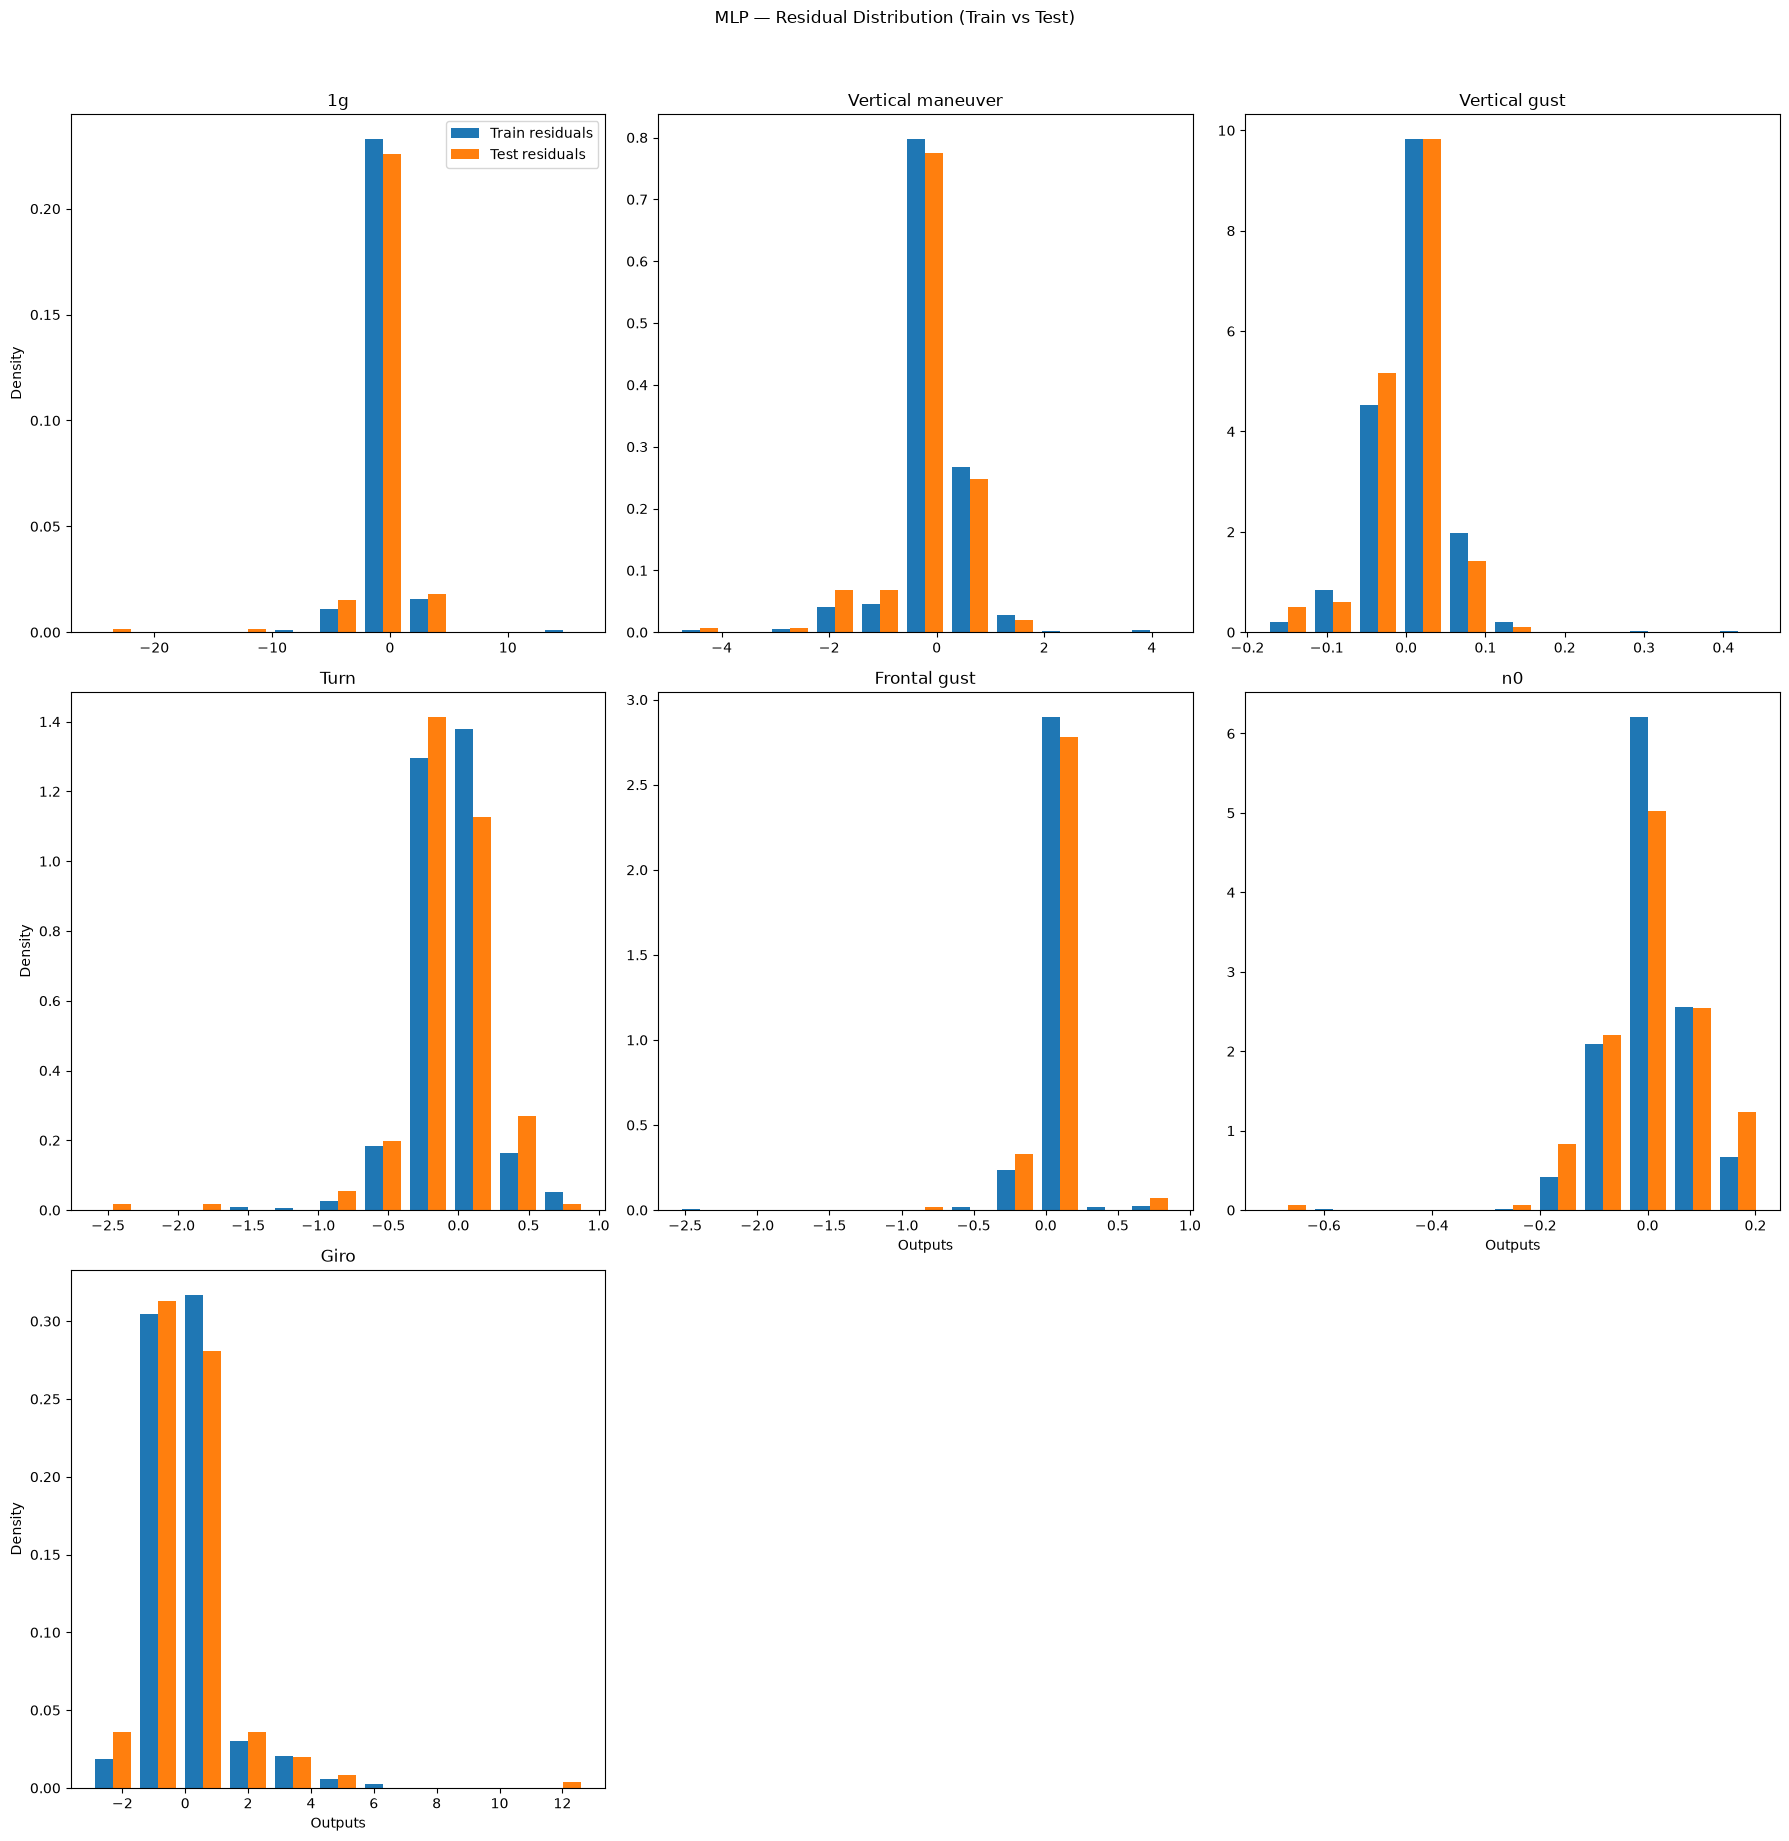

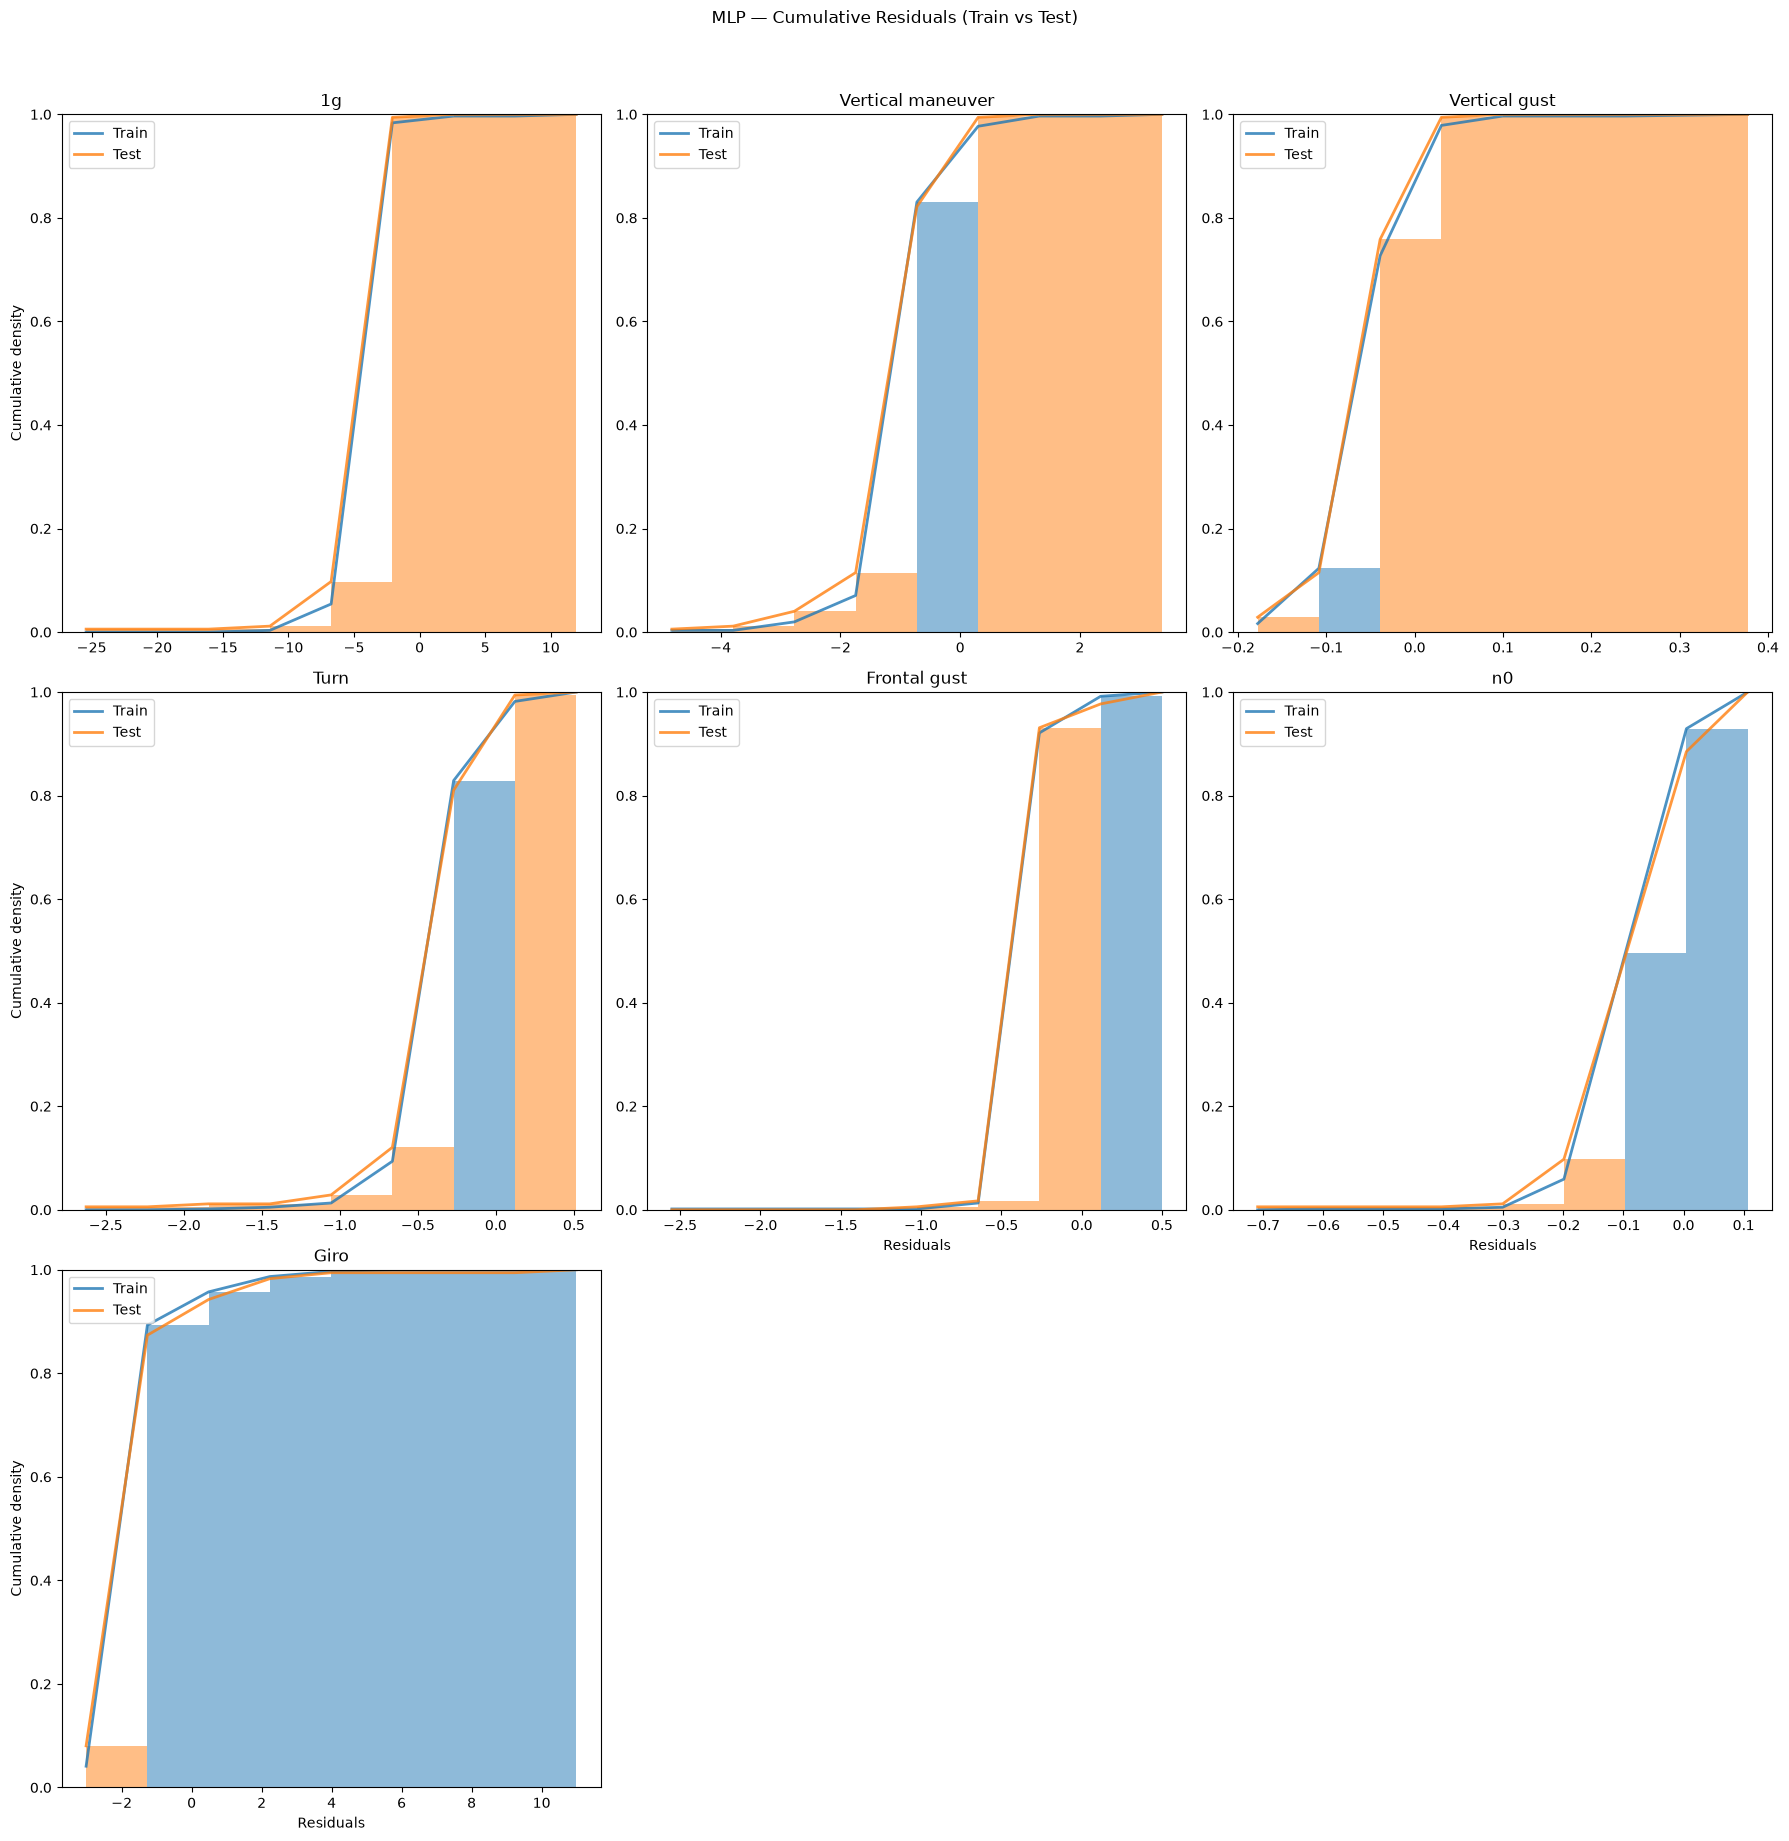

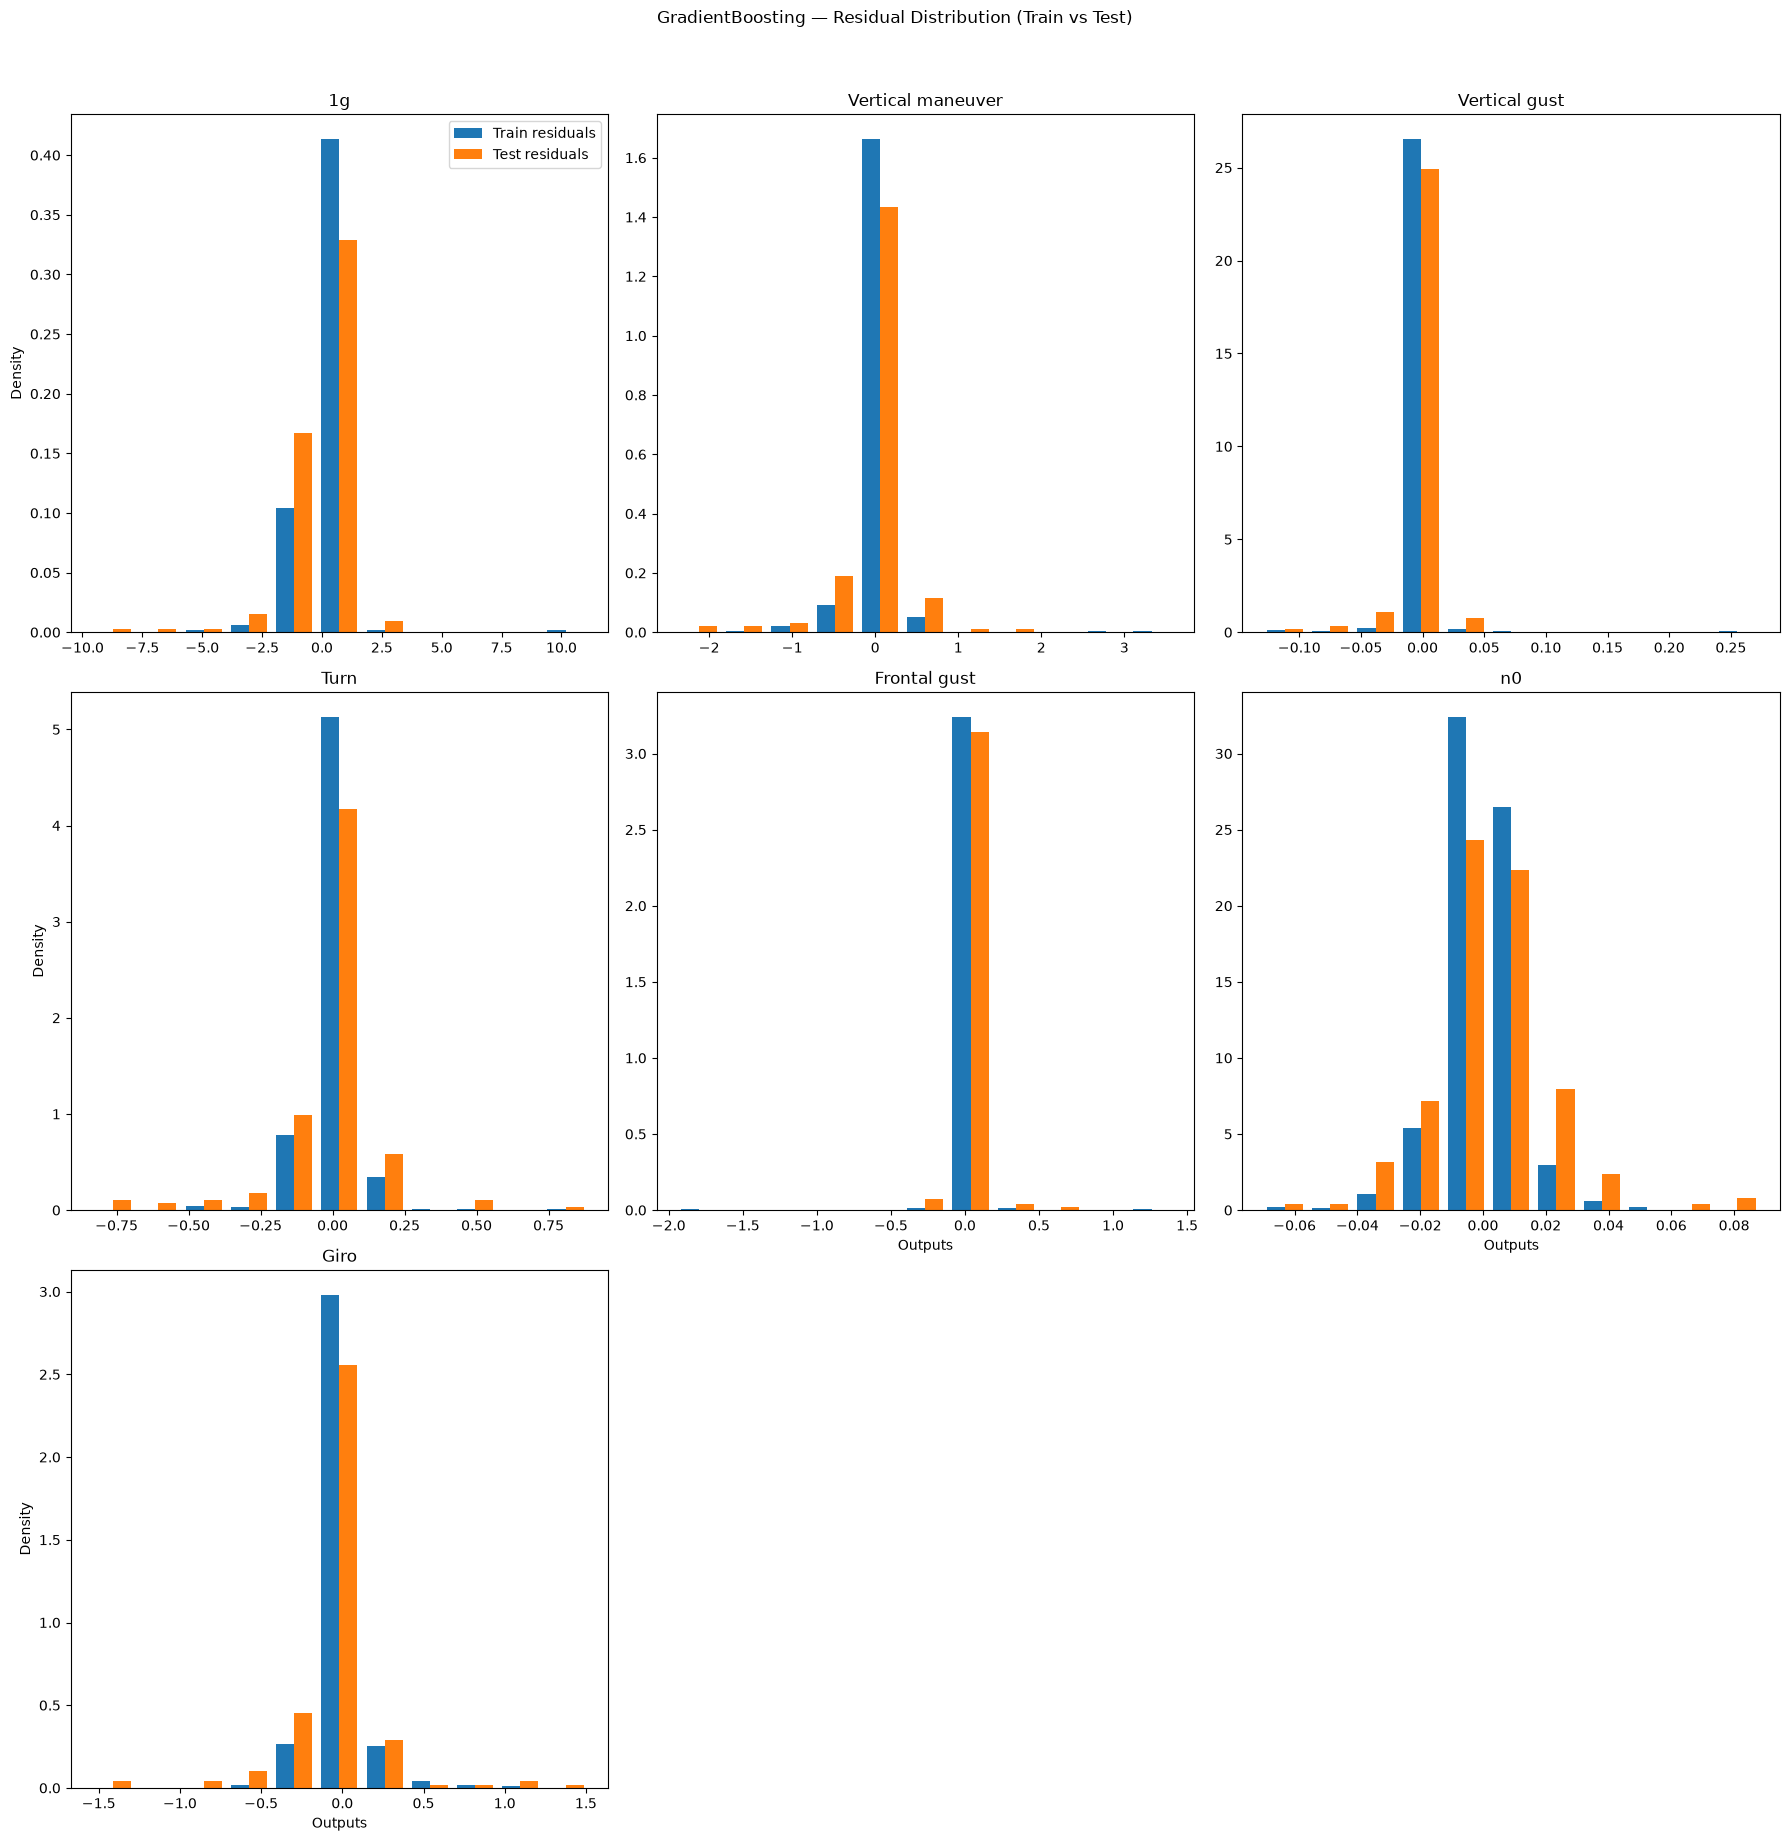

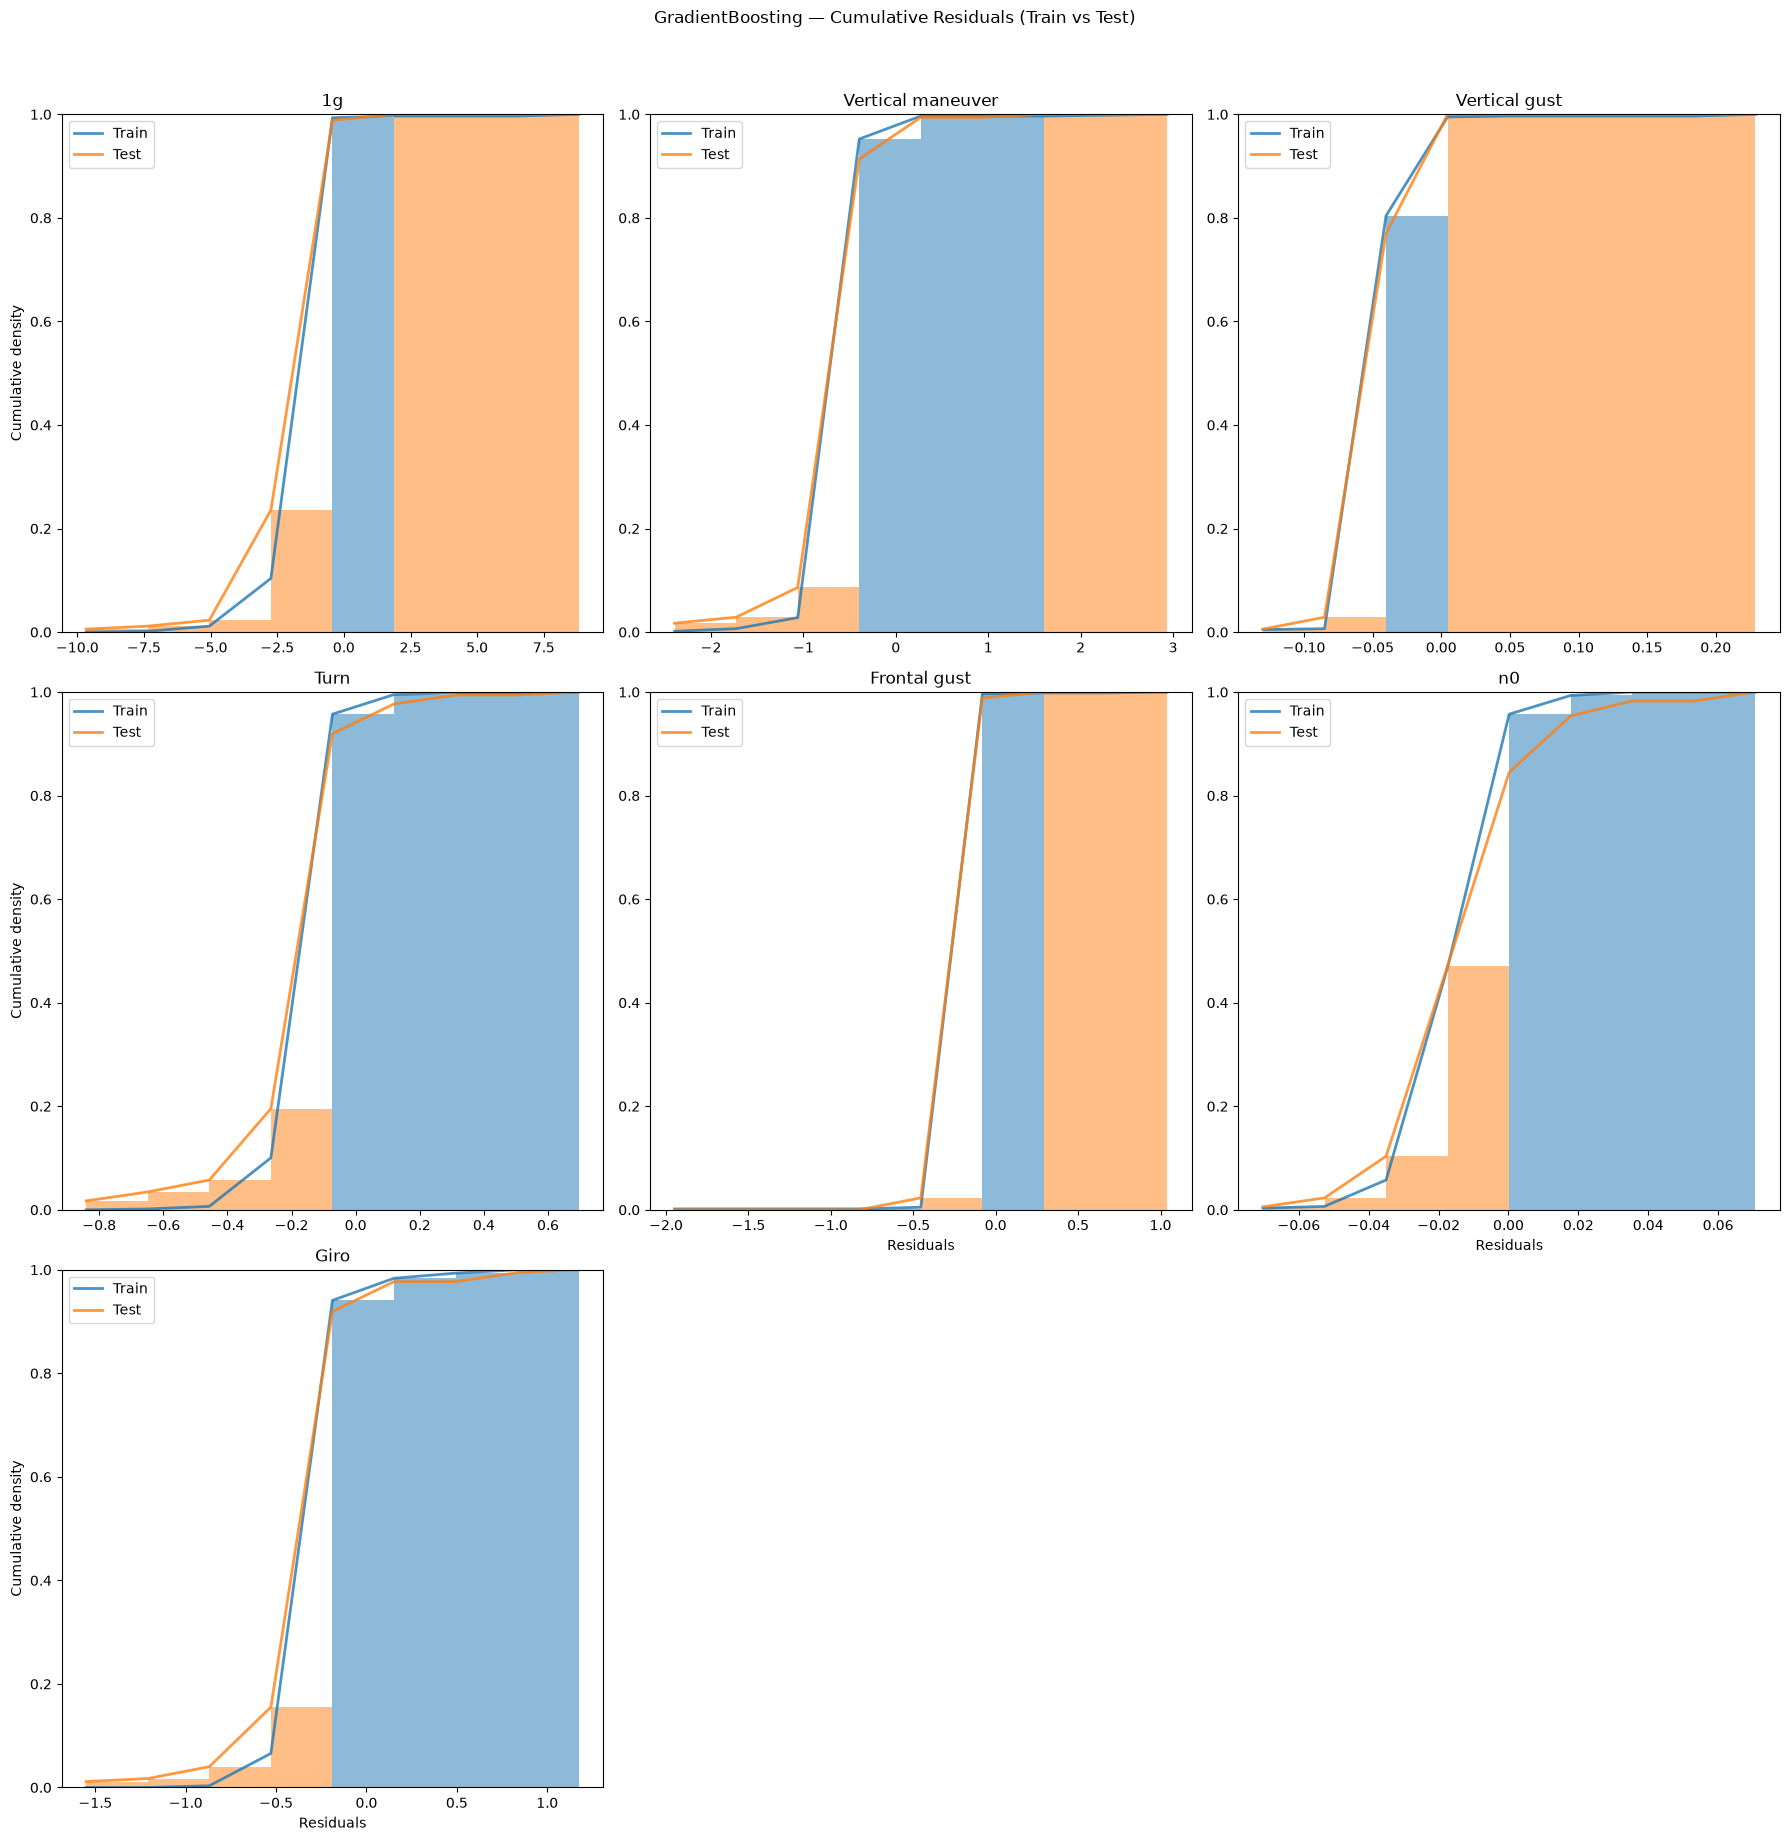

In [9]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from validationlib.plots.hist import doubleHistogram
from validationlib.plots.cumu import doublecumulative

ms = workflow.metadata.get_step_data(['metadata', 'Model_Selection'])
outputs = ms['outputs']
models_info = workflow.metadata.get_step_data(['metadata', 'Model_Training', 'Models'])

for info in models_info:
    label = info['label']

    train_res = pd.DataFrame(
        {col: Train_set[col].values - train_output[f'{label}__{col}'].values for col in outputs}
    )
    test_res = pd.DataFrame(
        {col: Test_set[col].values - model_output[f'{label}__{col}'].values for col in outputs}
    )

    # Histogram
    fig = doubleHistogram(
        train_res, test_res,
        x1label='Train residuals', x2label='Test residuals', xlabel='Outputs',
        multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
    )
    fig.suptitle(f'{label} — Residual Distribution (Train vs Test)', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # Cumulative
    fig2 = doublecumulative(
        train_res, test_res,
        label1='Train', label2='Test', xlabel='Residuals',
        multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
    )
    fig2.suptitle(f'{label} — Cumulative Residuals (Train vs Test)', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close(fig2)

#### 9.3 Validation against requirements

In [10]:
from model_validation.validation import validate
validate(workflow, metrics)

2026-07-01 11:39:30 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'validate'

  Output                      Metric          Target                 MLPGradientBoosting
  ------------------------------------------------------------------------------------
  1g                          quantile90      0.1000      ✓     0.0473✓     0.0257
  Vertical maneuver           quantile90      0.1000      ✓     0.0554✓     0.0318
  Vertical gust               quantile90      0.1000      ✓     0.0918✓     0.0262
  Turn                        quantile90      0.1000      ✓     0.0783✓     0.0351
  Frontal gust                quantile90      0.1000      ✗    11.3300✗     0.2795
  n0                          quantile90      0.1000      ✓     0.0723✓     0.0149
  Giro                        quantile90      0.1000      ✗     0.9005✗     0.2215


#### 9.3b Validation Summary — Interactive Table
Pass/fail per model and output, colour-coded.

In [11]:
import ipywidgets as widgets
import pandas as pd
from IPython.display import display

validation_results = workflow.metadata.get_step_data(['metadata', 'Model_Validation', 'validation_results'])
models_info_w = workflow.metadata.get_step_data(['metadata', 'Model_Training', 'Models'])
labels_w = [m['label'] for m in models_info_w]

rows = []
for vr in validation_results:
    row = {'Output': vr['output'], 'Metric': vr['metric'], 'Target': f"< {vr['target']}"}
    for lbl in labels_w:
        m = vr['models'].get(lbl, {})
        score, passed = m.get('score'), m.get('passed')
        row[lbl] = (f"{'✅' if passed else '❌'} {score:.4f}") if score is not None else '?'
    rows.append(row)

df_val = pd.DataFrame(rows).set_index('Output')

def color_cell(val):
    if '✅' in str(val): return 'background-color:#d4edda; color:#155724'
    if '❌' in str(val): return 'background-color:#f8d7da; color:#721c24'
    return ''

styled = df_val.style.applymap(color_cell, subset=labels_w).set_caption('Validation Results')
display(styled)

/var/folders/p1/nzt7bhk56jn6tj9cf8sbh8ym0000gn/T/ipykernel_46277/3740910048.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df_val.style.applymap(color_cell, subset=labels_w).set_caption('Validation Results')


,Metric,Target,MLP,GradientBoosting
Output,,,,
1g,quantile90,< 0.1,✅ 0.0473,✅ 0.0257
Vertical maneuver,quantile90,< 0.1,✅ 0.0554,✅ 0.0318
Vertical gust,quantile90,< 0.1,✅ 0.0918,✅ 0.0262
Turn,quantile90,< 0.1,✅ 0.0783,✅ 0.0351
Frontal gust,quantile90,< 0.1,❌ 11.3300,❌ 0.2795
n0,quantile90,< 0.1,✅ 0.0723,✅ 0.0149
Giro,quantile90,< 0.1,❌ 0.9005,❌ 0.2215


#### 9.4 Plots

2026-07-01 11:39:30 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'plot'


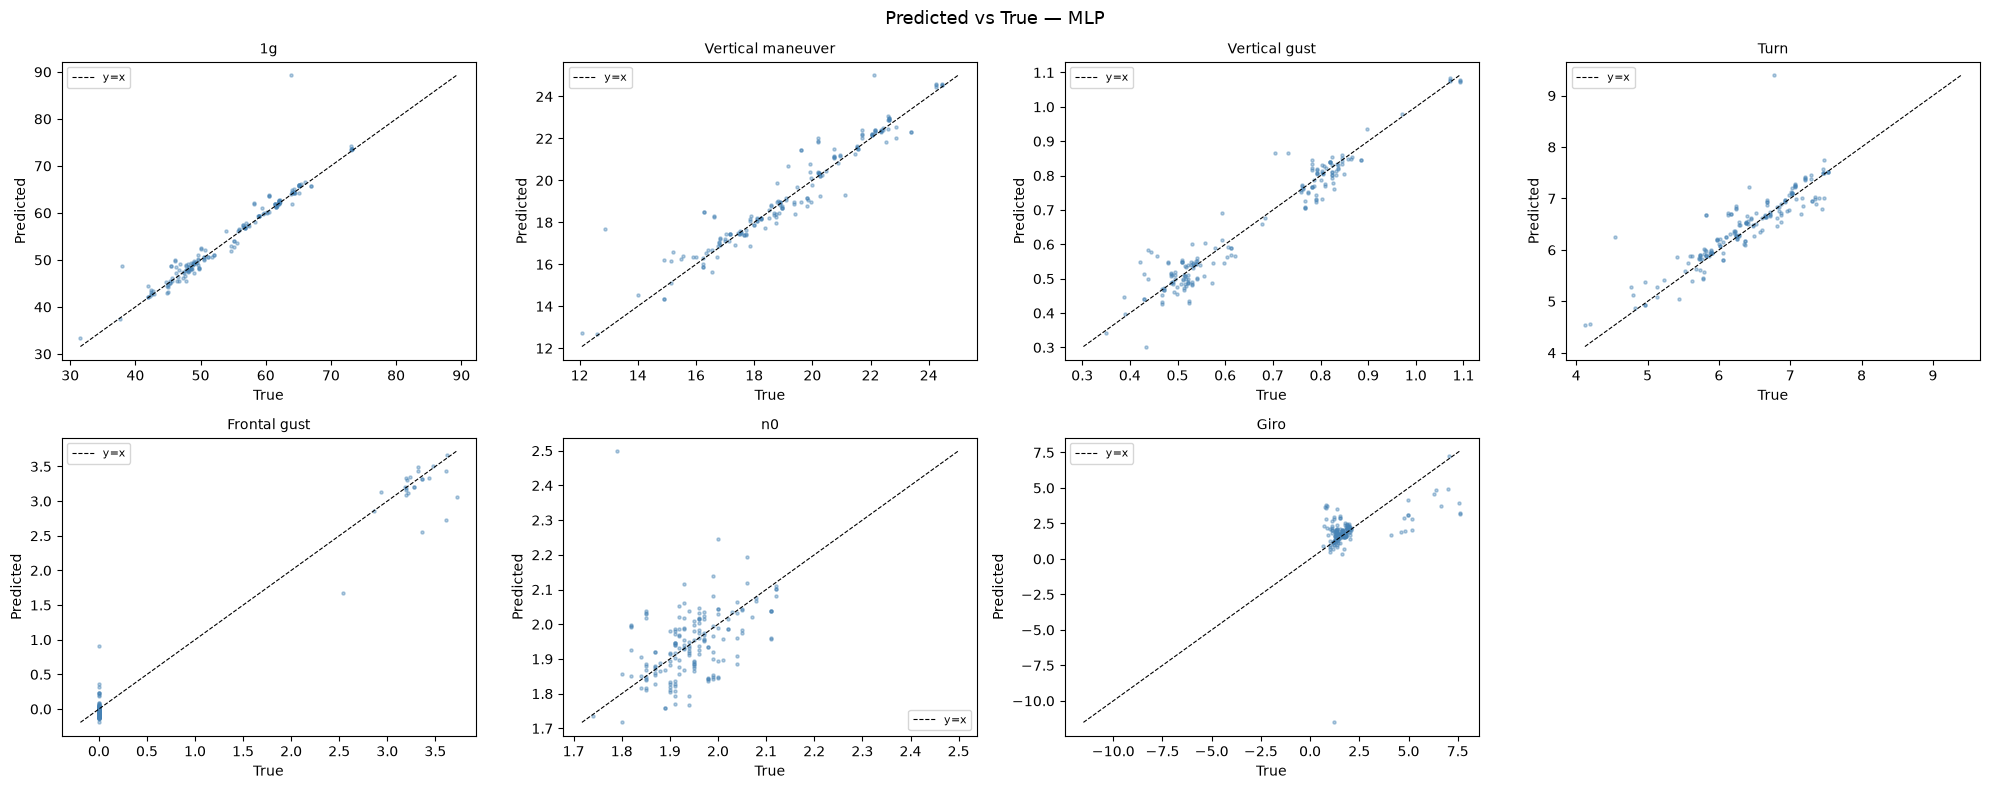

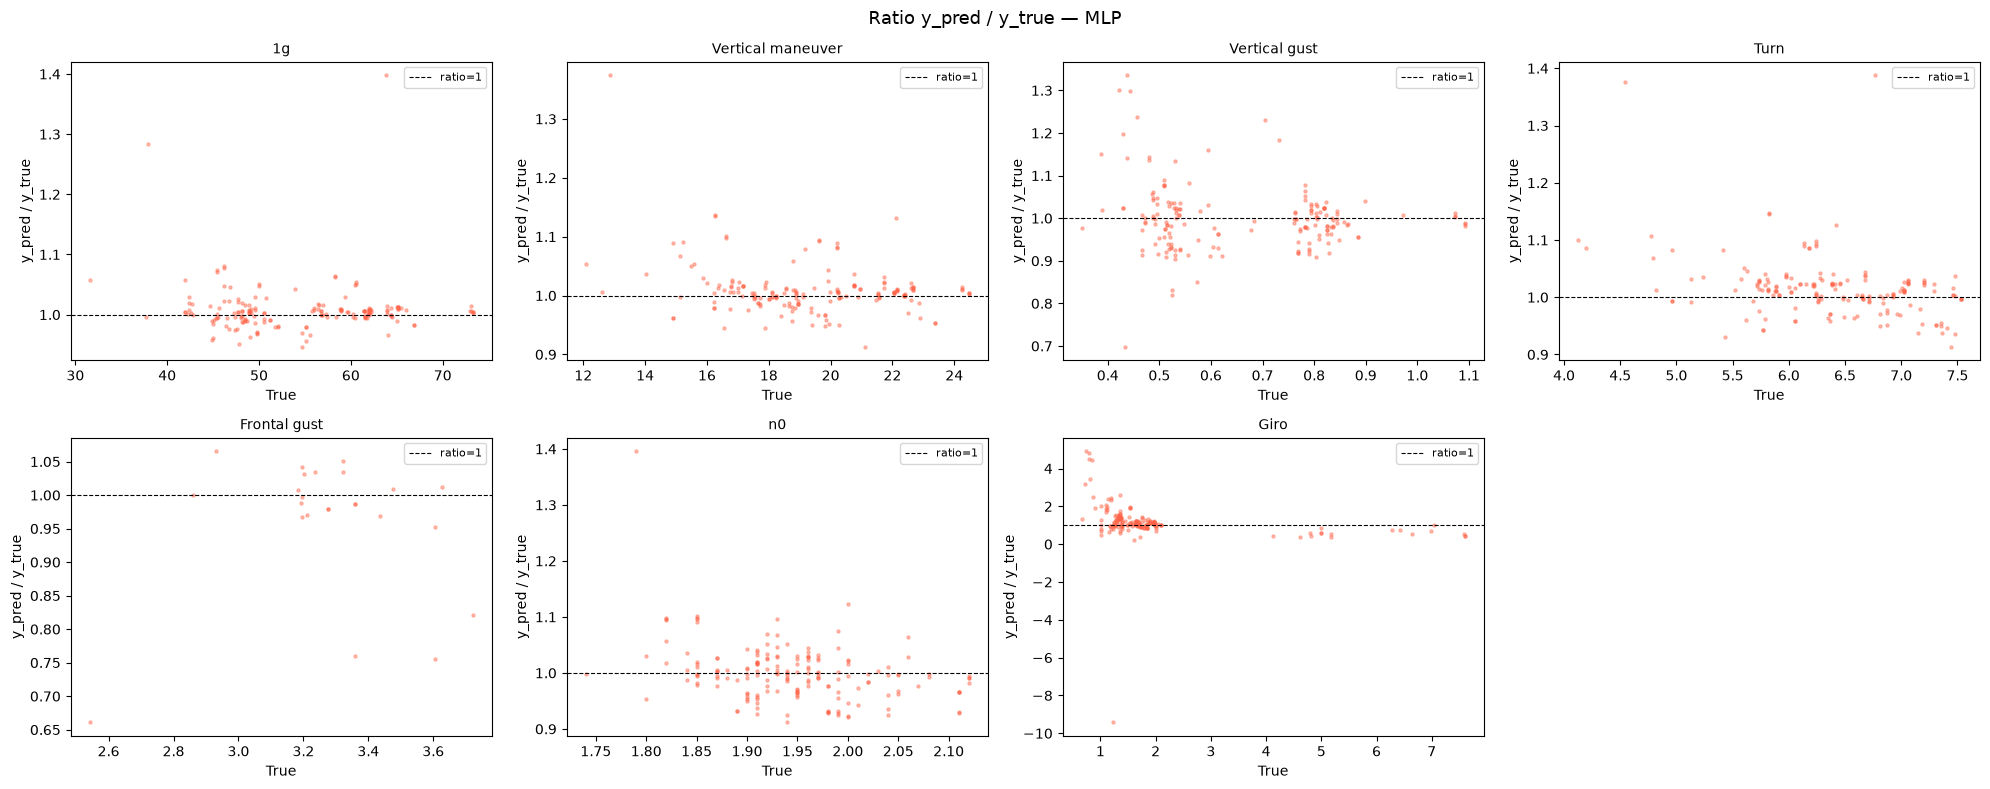

[MLP] scatter → scatter_MLP.png   ratio → ratio_MLP.png


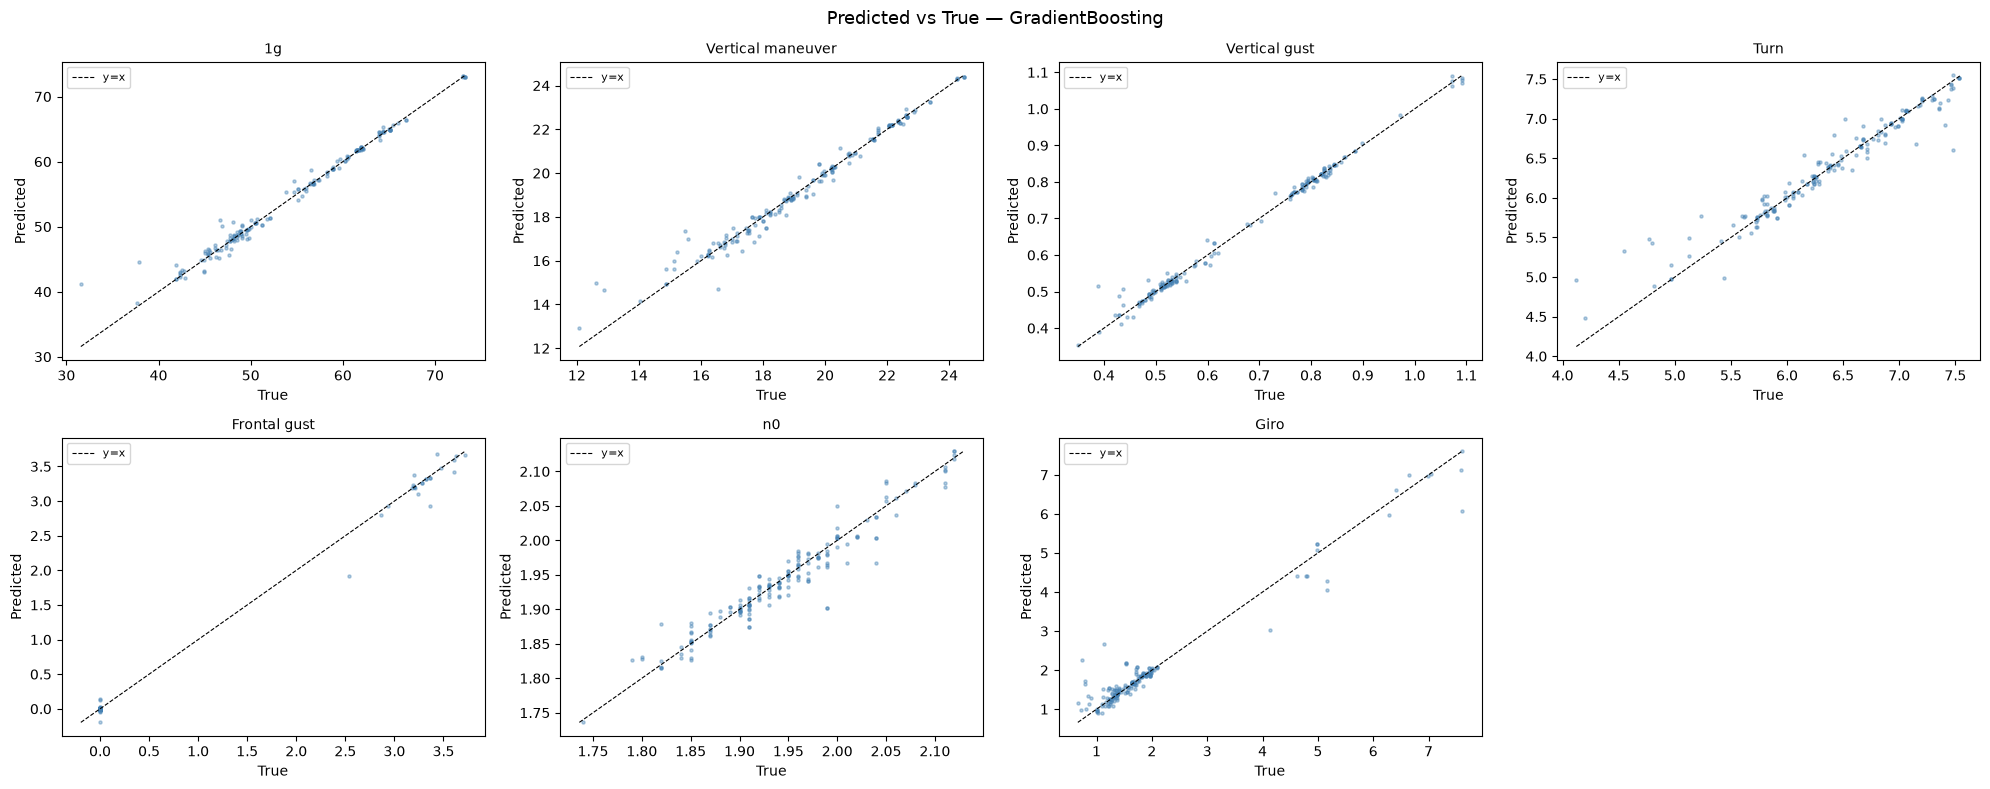

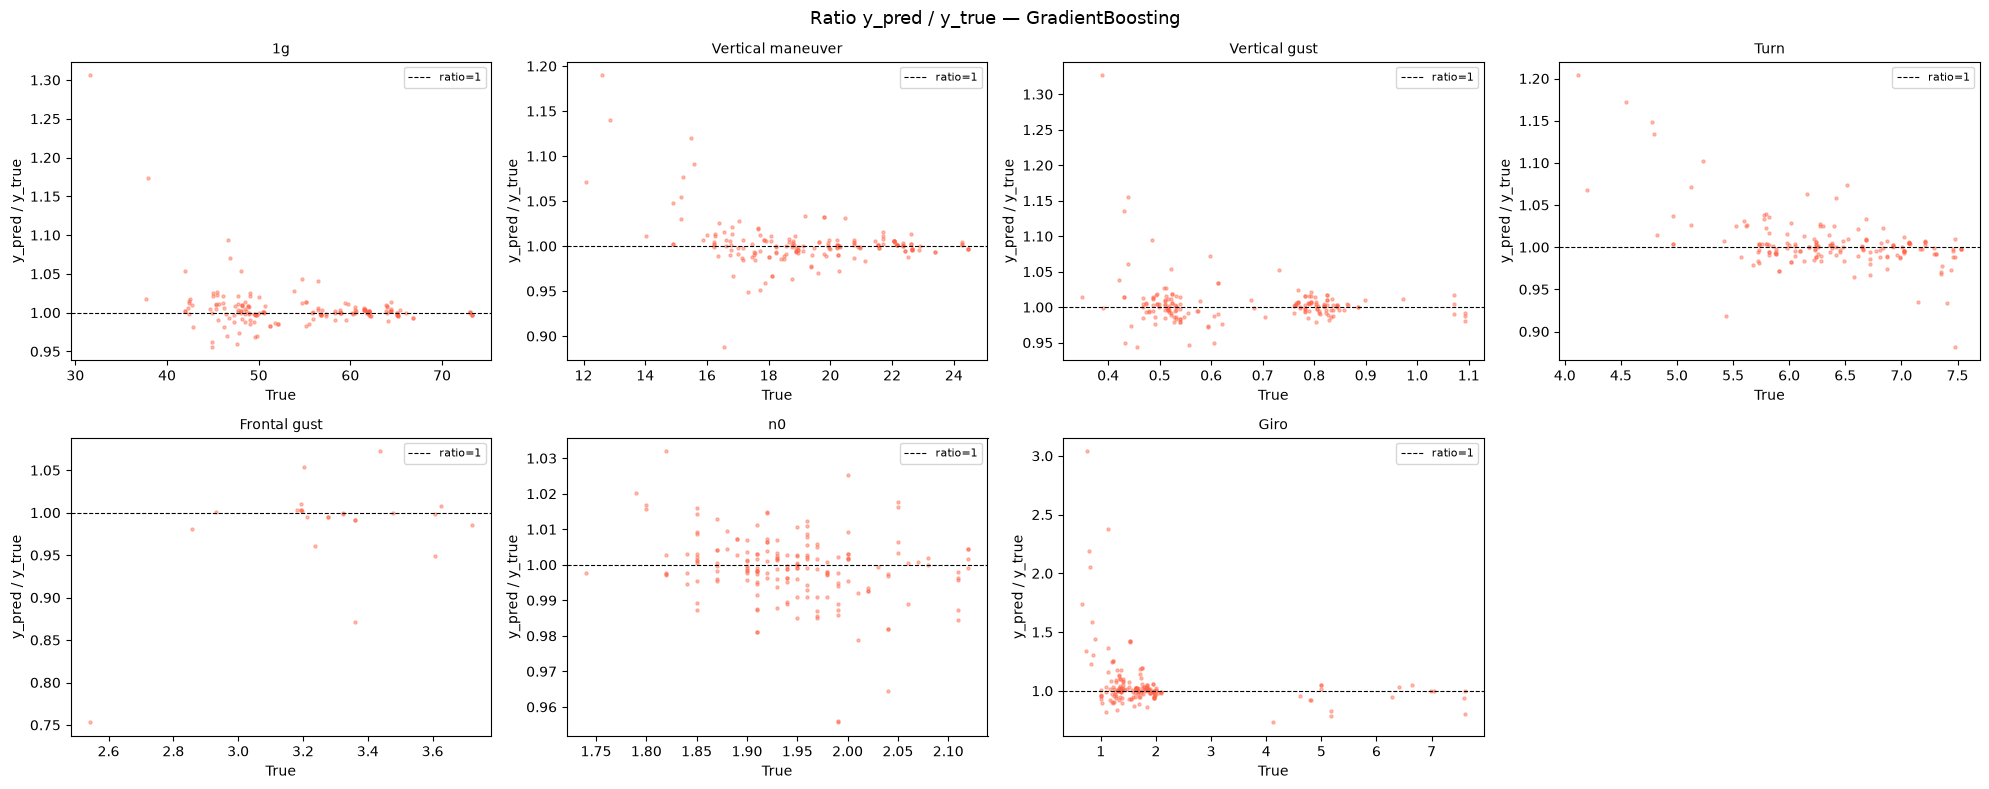

[GradientBoosting] scatter → scatter_GradientBoosting.png   ratio → ratio_GradientBoosting.png


In [12]:
%matplotlib inline
from model_validation.visualize import plot
plot(workflow, Test_set, model_output)

#### 9.4b Interactive Scatter Explorer
Select model and output to explore predictions.

In [13]:
%matplotlib inline
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display

ms_w      = workflow.metadata.get_step_data(["metadata", "Model_Selection"])
outputs_w = ms_w["outputs"]
mi_w      = workflow.metadata.get_step_data(["metadata", "Model_Training", "Models"])
labels_w  = [m["label"] for m in mi_w]

model_dd  = widgets.Dropdown(options=labels_w,  description="Model:",  layout=widgets.Layout(width="180px"))
output_dd = widgets.Dropdown(options=outputs_w, description="Output:", layout=widgets.Layout(width="220px"))
out_w     = widgets.Output()

def update_scatter(*_):
    label = model_dd.value
    col   = output_dd.value
    with out_w:
        out_w.clear_output(wait=True)
        y_true = Test_set[col].values
        y_pred = model_output[f"{label}__{col}"].values
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        axes[0].plot([lo, hi], [lo, hi], "k--", lw=0.8, label="y = x")
        axes[0].scatter(y_true, y_pred, s=8, alpha=0.45, color="steelblue")
        axes[0].set_xlabel("True"); axes[0].set_ylabel("Predicted")
        axes[0].set_title(f"{label} — {col}  (predicted vs true)")
        axes[0].legend(fontsize=8)
        mask  = y_true != 0
        ratio = y_pred[mask] / y_true[mask]
        axes[1].axhline(1.0, color="k", lw=0.8, linestyle="--", label="ratio = 1")
        axes[1].scatter(y_true[mask], ratio, s=8, alpha=0.45, color="tomato")
        axes[1].set_xlabel("True"); axes[1].set_ylabel("y_pred / y_true")
        axes[1].set_title(f"{label} — {col}  (ratio)")
        axes[1].legend(fontsize=8)
        plt.tight_layout()
        plt.show()

model_dd.observe(update_scatter, names="value")
output_dd.observe(update_scatter, names="value")
update_scatter()
display(widgets.HBox([model_dd, output_dd]), out_w)

Output()

#### 9.5 Validation Report
Exports CSVs per model and runs `validation_script.py` to produce a full HTML validation report:
- Data EDA (inputs + outputs: statistics, histograms, cumulative distributions)
- Train-test split check (doubleHistogram + KS/AD + VTP method)
- Error quantification: Residue and Absolute Error — statistics, percentiles, cumulative, P(E|X), P(E|Y)
- Predicted vs Ground Truth: scatterplot + 2-D histogram
- P(E) goodness-of-fit to parametric distributions
- Bias detection: trend tables (Pearson, Spearman) + boxplot/violin + Levene/ANOVA/KW tests
- Uncertainty: global, local-output, local-input, combined (BinnedUncertaintyModel + ModelCoverage)

Reports are saved to `data/artifacts/validation_reports/`.

In [14]:
import os, sys, subprocess
from pathlib import Path
from model_validation.export_validation_csvs import export_validation_csvs

# Export CSVs for each model
print("Exporting validation CSVs...")
csv_dirs = export_validation_csvs(
    workflow,
    Train_set, Val_set, Test_set,
    train_output, val_output, model_output,
)

# Run validation_script.py for each model
script_path = Path(workflow.config["data.folder"]).parent / "python_nodes_library" / "model_validation" / "validation_script.py"
output_dir     = Path(workflow.config["artifacts.folder"]) / "validation_reports"
output_dir.mkdir(exist_ok=True)

ms_w = workflow.metadata.get_step_data(["metadata", "Model_Selection"])
num_inputs_w = Train_set[ms_w["inputs"]].select_dtypes(include="number").columns.tolist()

for label, csv_dir in csv_dirs.items():
    print(f"\nRunning validation report for {label}...")
    cmd = [
        sys.executable, str(script_path),
        "-d", str(csv_dir),
        "-n", label,
        "-o", str(output_dir),
        "--exclude_warnings",
        "--splitting_variables", *num_inputs_w,
    ]
    result = subprocess.run(
        cmd, capture_output=True, text=True,
        env={**os.environ,
             "PYTHONPATH": "/Users/martaarnabatmartin/Desktop/Pipelines/src",
             "MLFLOW_ALLOW_FILE_STORE": "true"},
    )
    if result.returncode == 0:
        report = output_dir / f"{label}_validation_output.html"
        print(f"  ✓ Report: {report}")
    else:
        print(f"  ✗ Error:\n{result.stderr[-800:]}")


Exporting validation CSVs...
  [MLP] CSVs → /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/artifacts/validation_MLP
  [GradientBoosting] CSVs → /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/artifacts/validation_GradientBoosting

Running validation report for MLP...
  ✓ Report: /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/artifacts/validation_reports/MLP_validation_output.html

Running validation report for GradientBoosting...
  ✓ Report: /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/artifacts/validation_reports/GradientBoosting_validation_output.html


#### 9.6 MLflow EDA Report
Logs a dedicated `EDA_Data_Report` run to MLflow with:
input/output distribution plots, correlation matrix, PCA coverage scatter,
split quality (VTP), KS p-values, R²/Q90/MAE per model, and summary CSVs.
Open the MLflow UI (`./start_jupyter.sh --mlflow`) to explore artefacts.

In [15]:
from tracking.mlflow_eda import log_eda

log_eda(
    workflow    = workflow,
    Train_set   = Train_set,
    Val_set     = Val_set,
    Test_set    = Test_set,
    model_output  = model_output,
    train_output  = train_output,
    metrics       = metrics,
    split_result  = split_result,
    ks_results    = ks_results,
)

[EDA] Run logged: ce2e6564fbc441999043ffe52837b7cf


### Save

In [16]:
workflow.save_metadata()

2026-07-01 11:41:20 - SurrogateFactoryLogs - INFO - Successfully saved workflow metadata to: /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/artifacts/metadata_UCFATIGUE_1.json
